In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

In [51]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    number3 : int
    number4 : int
    op1 : str
    op2 : str
    final1 : int
    final2 : int

In [52]:
def adding_node_1(state : AgentState) -> AgentState:
    state['final1'] = state['number1'] + state['number2']
    return state

In [53]:
def subtracting_node_1(state : AgentState) -> AgentState:
    state["final1"] = state["number1"] - state["number2"]
    return state

In [ ]:
def router_1(state : AgentState) -> str:
    if state['op1'] == '+':
        return "adding"
    elif state['op1'] == '-':
        return "subtracting"

In [55]:
def adding_node_2(state : AgentState) -> AgentState:
    state['final2'] = state['number3'] + state['number4']
    return state

In [56]:
def subtracting_node_2(state : AgentState) -> AgentState:
    state["final2"] = state["number3"] - state["number4"]
    return state

In [ ]:
def router_2(state : AgentState) -> str:
    if state['op2'] == '+':
        return "adding"
    elif state['op2'] == '-':
        return "subtracting"

In [58]:
graph = StateGraph(AgentState)

graph.add_node("adding_node_1" , adding_node_1)
graph.add_node("subtracting_node_1" , subtracting_node_1)

graph.add_node("adding_node_2" , adding_node_2)
graph.add_node("subtracting_node_2" , subtracting_node_2)

graph.add_node("router_1" , lambda state : state)
graph.add_node("router_2" , lambda state : state)

graph.set_entry_point("router_1")

graph.add_conditional_edges(
    "router_1",
    router_1,
    {
        # Edge : Node
        "adding" : "adding_node_1",
        "subtracting" : "subtracting_node_1"
    }
)

graph.add_edge("adding_node_1" , "router_2")
graph.add_edge("subtracting_node_1" , "router_2")

graph.add_conditional_edges(
    "router_2",
    router_2,
    {
        # Edge : Node
        "adding" : "adding_node_2",
        "subtracting" : "subtracting_node_2"
    }
)

graph.add_edge("adding_node_2" , END)
graph.add_edge("subtracting_node_2" , END)

app = graph.compile()

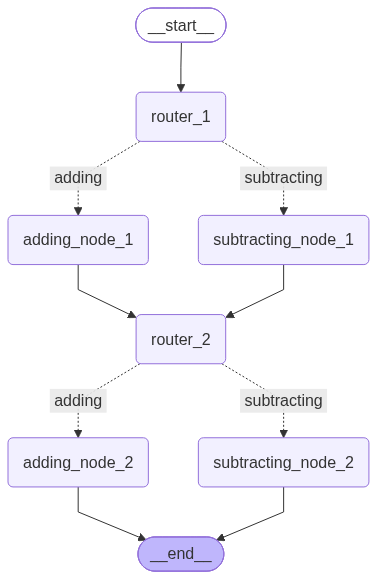

In [59]:
app

In [60]:
app.invoke({
    'number1': 5,
    'number2': 5,
    'number3': 1,
    'number4': 2,
    'op1': "-",
    'op2': "+",
})

{'number1': 5,
 'number2': 5,
 'number3': 1,
 'number4': 2,
 'op1': '-',
 'op2': '+',
 'final1': 0,
 'final2': 3}